In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys, os
sys.path.append(os.path.abspath('../..'))
import torch
import torch.nn as nn

from mounirood.tester import PonderationTester
from mounirood.datasets import get_y
from mounirood.framework import FrameworkFactory
from mounirood.modality_fusion import calc_perturbations, CoefficientPonderator
from mounirood.datasets import get_dataloader, get_y
from mounirood.eval_functions import visualize, train, performance_report
#from mounirood.eval_functions import auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite
from sklearn import metrics
from sklearn.model_selection import train_test_split

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

Matplotlib created a temporary cache directory at /tmp/matplotlib-e_k4b9qc because the default path (/local/maouche/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Failure prediction:
- Essayer de prédire si le modèle va se tromper ou pas.
- Uniquement sur données ID.
- Récupérer les confs, preds et labels
- Utiliser les méthodes (MSP direct, pondération perturbations, aggrégation max/min/mean etc., )

# Ash

## Near OOD

### Création des datasets

In [5]:
framework = FrameworkFactory("near_ood")
layer_proc = "ash"

conf = framework.get_confs("id", layer_proc)
pred = framework.get_preds_near_vf("id", layer_proc)
labels = framework.get_saved_files_near_vf("label", "id", layer_proc)

failure_gt = {}
for dataset_name, values in list(pred.items()):
    failure_gt[dataset_name] = np.where(pred[dataset_name].transpose()[0] == labels[dataset_name].transpose()[0], 0, 1).reshape(-1,1) # 1 == Failure

In [14]:
X = conf
Y = failure_gt
datasets = ["HMDB", "UCF", "EPIC"]
data = {}
for dataset in datasets:    
    X_train, X_test, y_train, y_test = train_test_split(
                    X[dataset], Y[dataset], stratify=Y[dataset], test_size=0.2, random_state=42)

    data[dataset] = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [15]:
with open("data_near.pkl", 'wb') as f:
    pickle.dump(data, f)

### Chargement des données

In [3]:
with open("/data/maouche/MultiOOD/_failure_prediction/fp_ash/data_near.pkl", 'rb') as f:
    data_all = pickle.load(f)

#### HMDB

In [4]:
data = data_all["HMDB"]

train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 

367 elements (array([0., 1.], dtype=float32), array([329,  38]))
92 elements (array([0., 1.], dtype=float32), array([82, 10]))


In [5]:
input_dim = 4  #ash sur tous + ash sur aucun + ash video + ash flow + ash audio
hidden_dim = 2
output_dim = 1

# Calcul des poids des classes
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

8.657894736842104

cuda


accuracy train:  0.8790352940559387


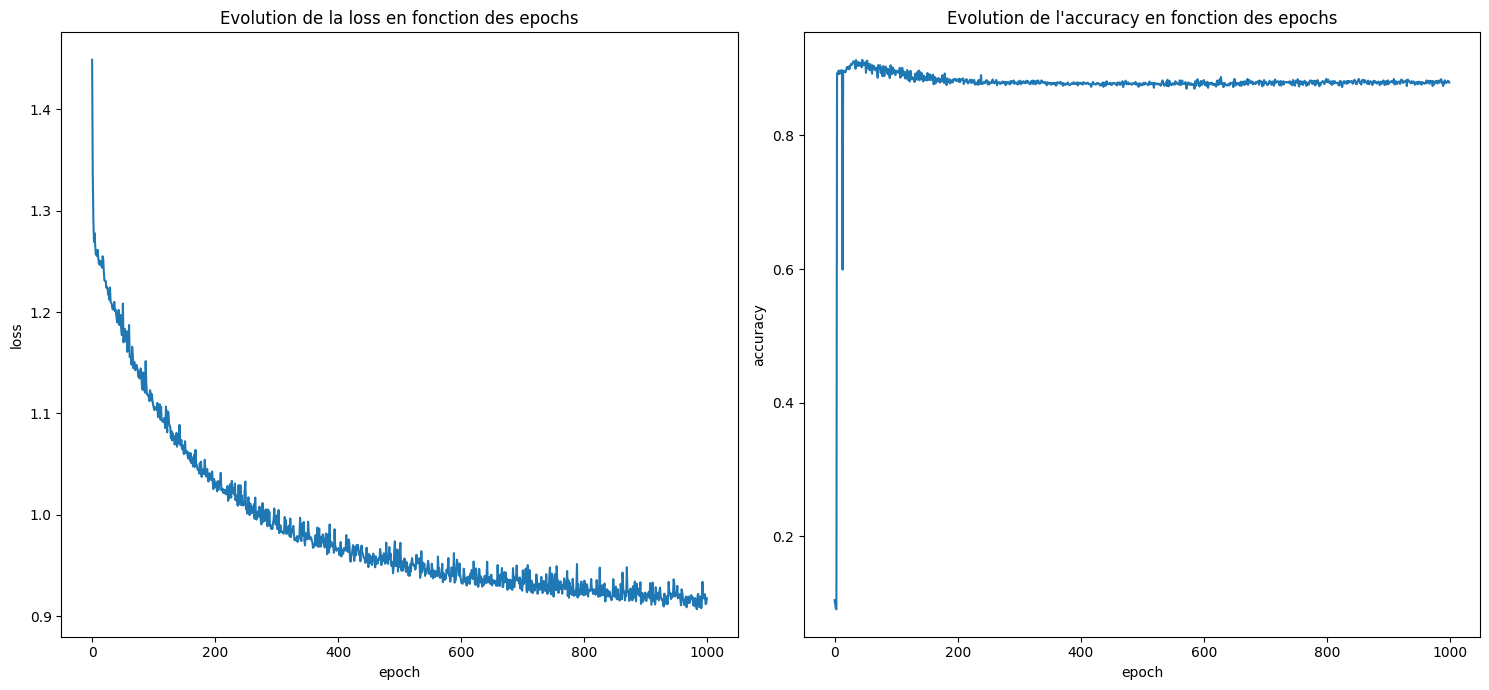

cuda
accuracy train:  0.8716216286023458


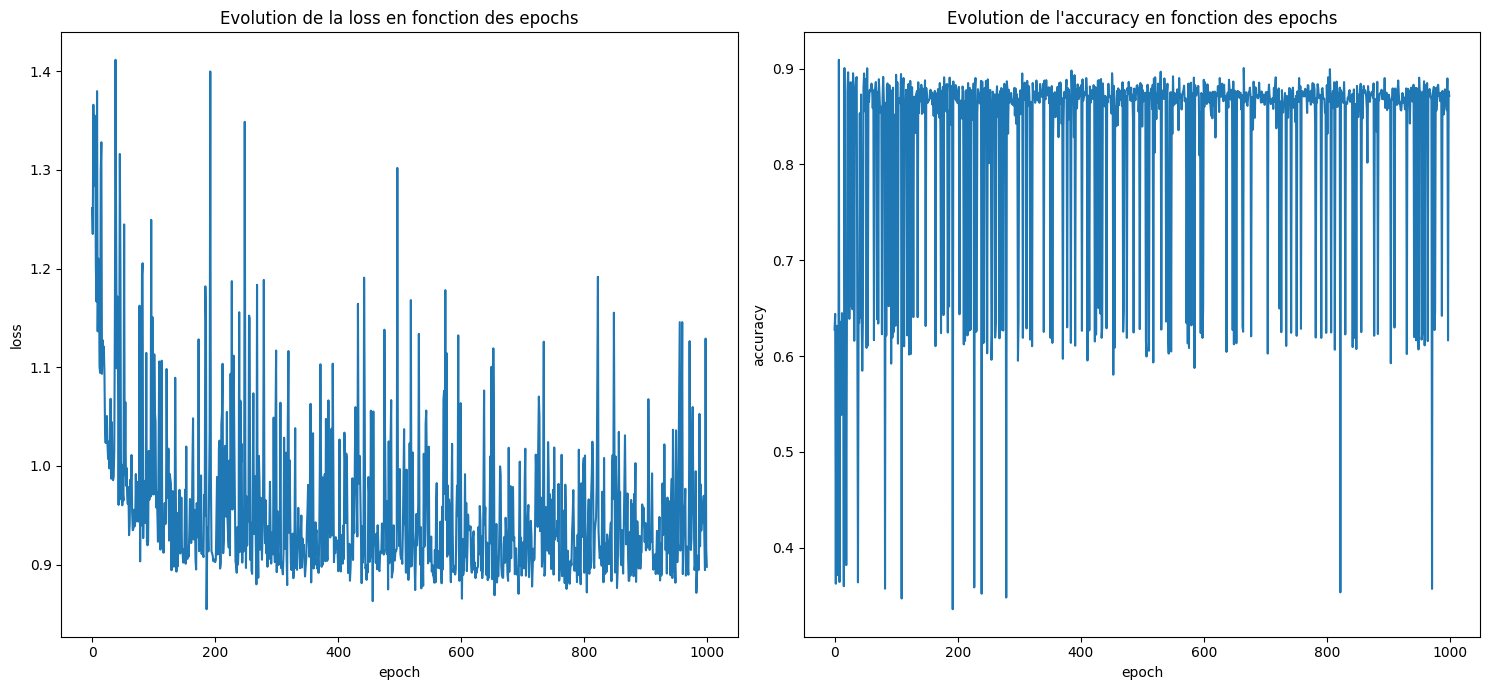

cuda
accuracy train:  0.8614161014556885


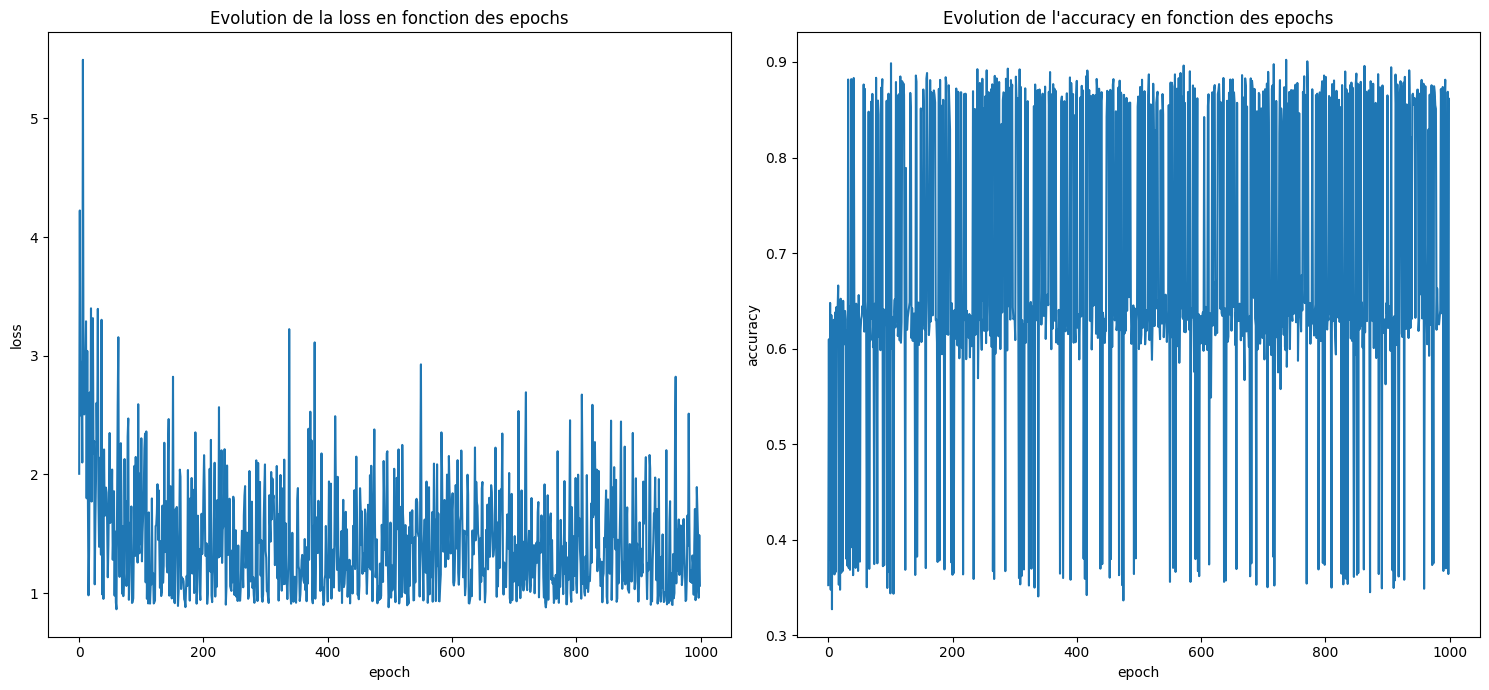

In [19]:
nb_epochs = 1000
models = {}
for lr in [1e-1, 1, 2]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)

    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [20]:
model = models[1e-1]
torch.save(model.state_dict(), "model_near_HMDB.pth")

Accuracy test:  0.8804
Séparabilité:


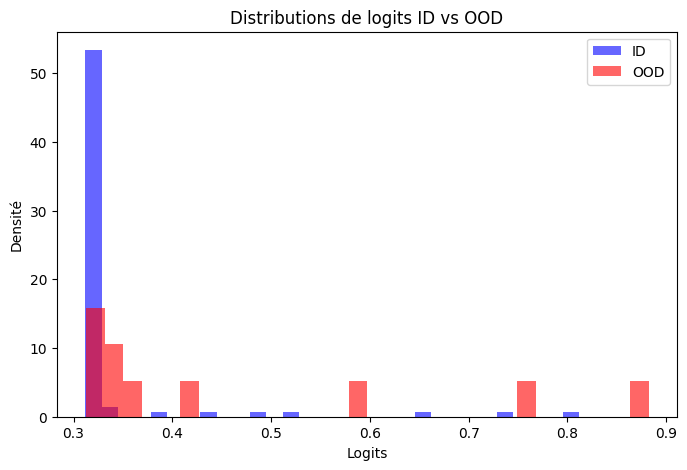

AUC ROC: 0.8951
FPR@TPR95: 0.2927

Correlation ID :  0.9418445036946864
Correlation OOD :  0.9333688625492519


,config,tout,video,flow
0,poids_near_ood,2.0811,0.9954,-3.6031
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0211,0.0137,0.0069


In [21]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, FrameworkFactory("near_ood"))

#### UCF

In [22]:
data = data_all["UCF"]

train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 

input_dim = 4  #ash sur tous + ash sur aucun + ash video + ash flow + ash audio
hidden_dim = 2
output_dim = 1

# Calcul des poids des classes
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

824 elements (array([0., 1.], dtype=float32), array([818,   6]))
206 elements (array([0., 1.], dtype=float32), array([204,   2]))


136.33333333333334

cuda


accuracy train:  0.9810267857142857


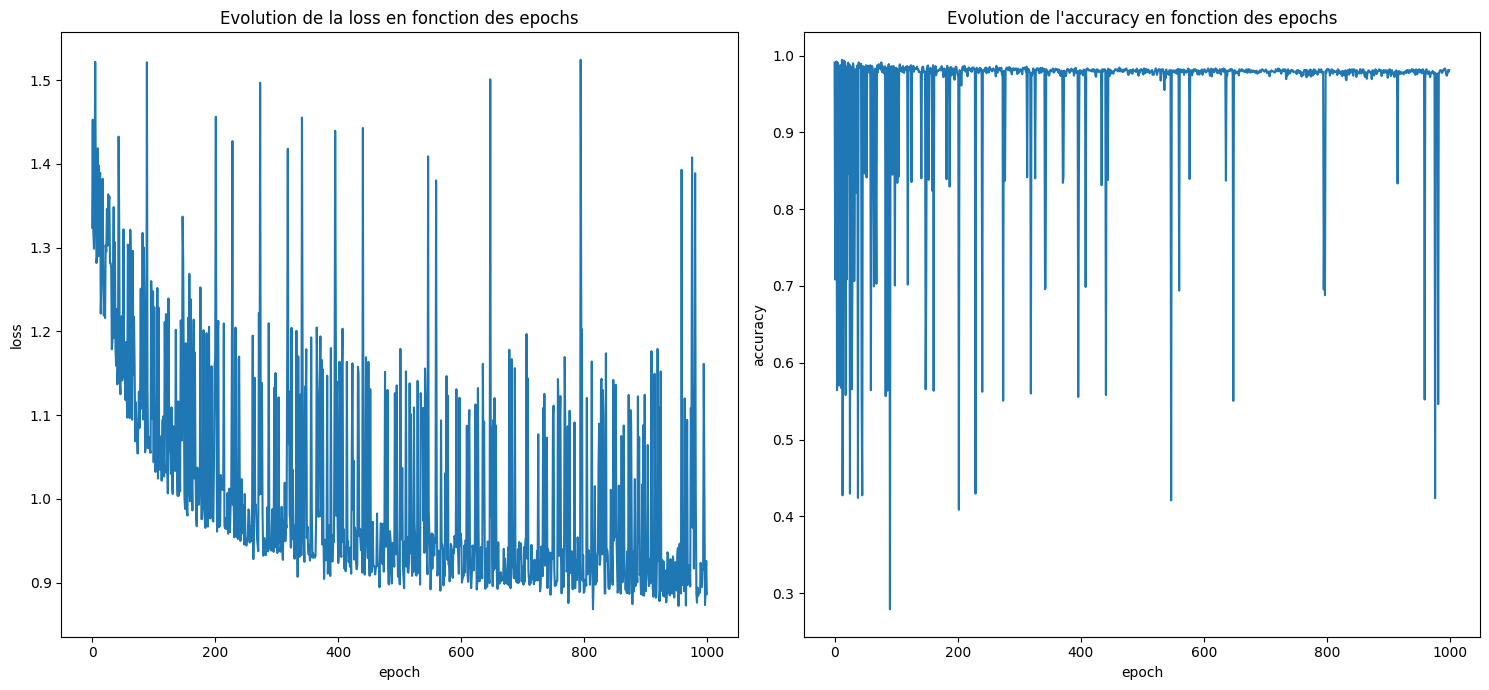

cuda
accuracy train:  0.8372130138533456


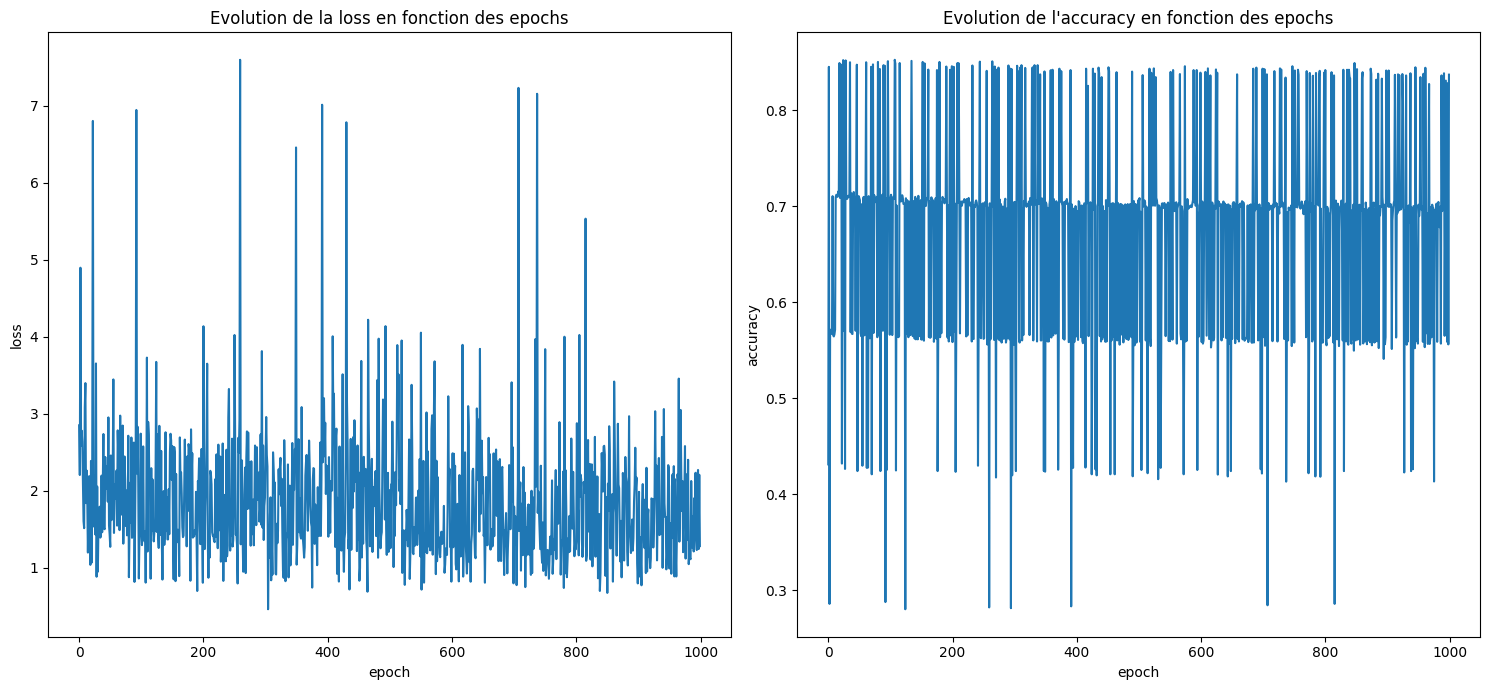

cuda
accuracy train:  0.6969068901879447


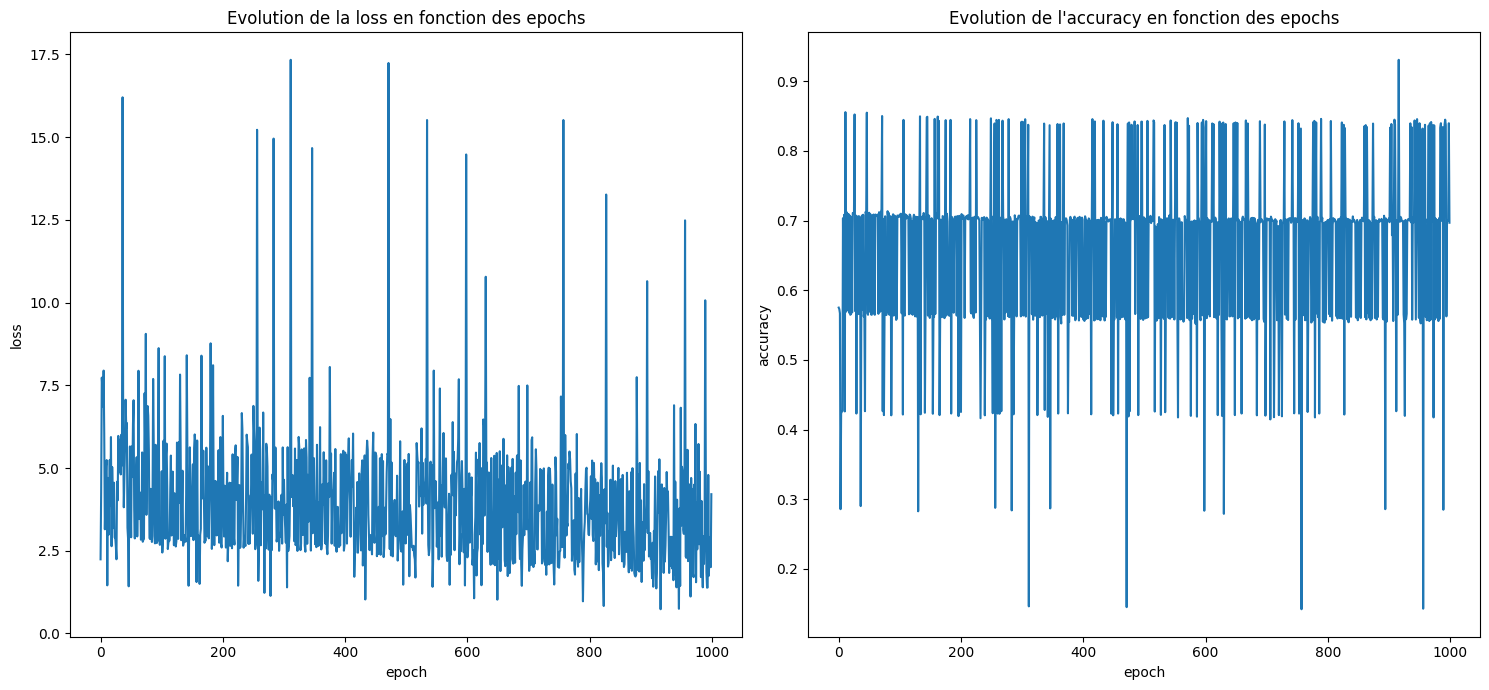

In [23]:
nb_epochs = 1000
models = {}
for lr in [1e-1, 1, 2]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)

    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [24]:
model = models[1e-1]
torch.save(model.state_dict(), "model_near_UCF.pth")

Accuracy test:  0.9806
Séparabilité:


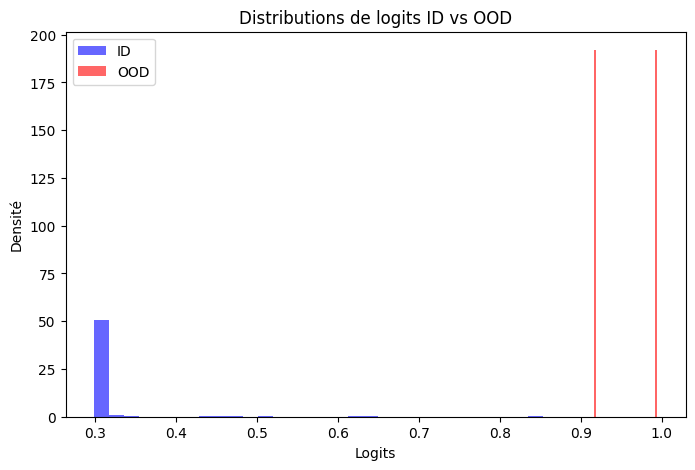

AUC ROC: 1.0
FPR@TPR95: 0.0

Correlation ID :  0.7534763030349271
Correlation OOD :  0.7372177991931556


,config,tout,video,flow
0,poids_near_ood,1.0401,2.1995,-3.4944
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0211,0.0137,0.0069


In [25]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, FrameworkFactory("near_ood"))

#### EPIC

In [6]:
data = data_all["EPIC"]

train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 

input_dim = 4  #ash sur tous + ash sur aucun + ash video + ash flow + ash audio
hidden_dim = 2
output_dim = 1

# Calcul des poids des classes
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

428 elements (array([0., 1.], dtype=float32), array([306, 122]))
108 elements (array([0., 1.], dtype=float32), array([77, 31]))


2.5081967213114753

cuda
accuracy train:  0.7091619372367859


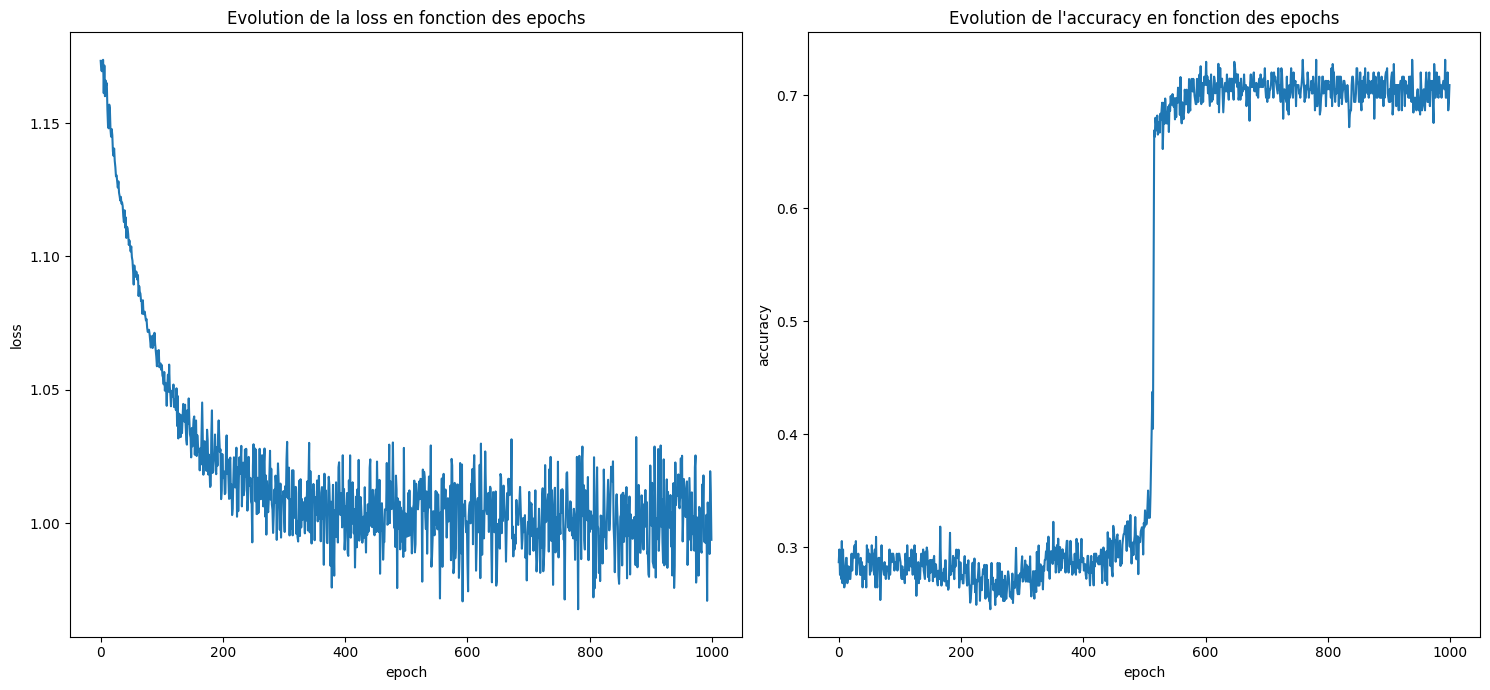

cuda
accuracy train:  0.7482244372367859


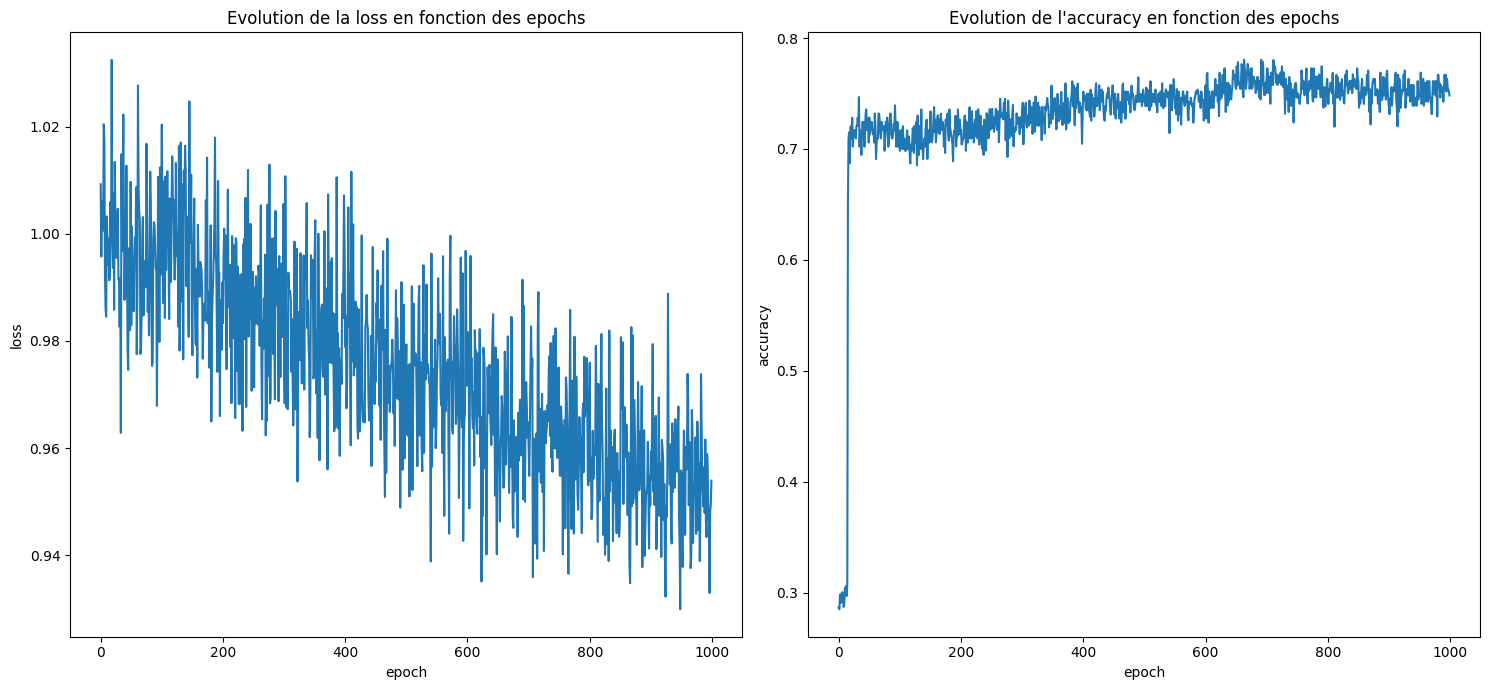

cuda
accuracy train:  0.7116477340459824


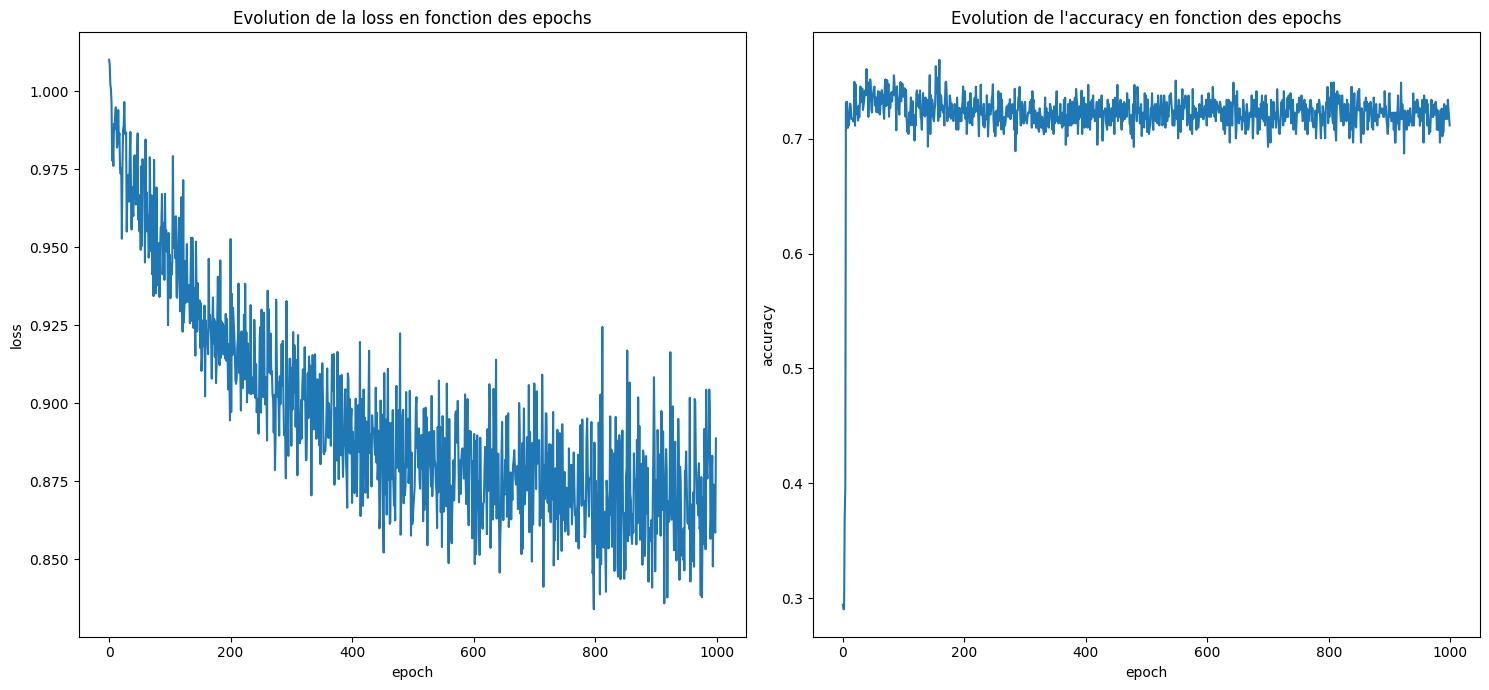

In [7]:
nb_epochs = 1000
models = {}
for lr in [1e-3, 1e-2, 1e-1]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)

    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [8]:
model = models[1e-2]
torch.save(model.state_dict(), "model_near_EPIC.pth")

Accuracy test:  0.713
Séparabilité:


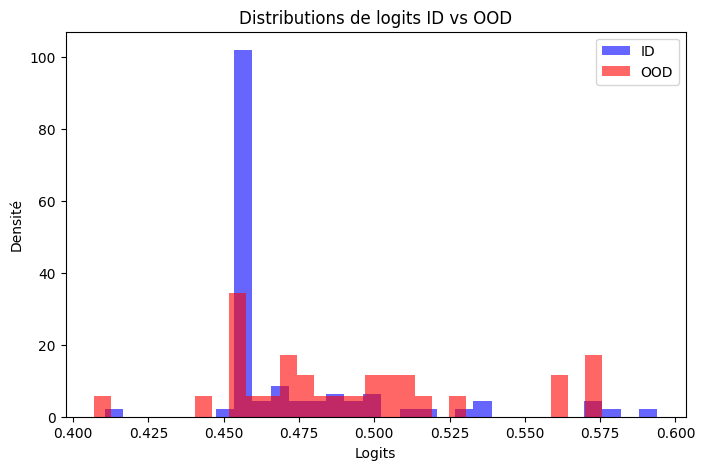

AUC ROC: 0.6956
FPR@TPR95: 0.987

Correlation ID :  0.9989022610423312
Correlation OOD :  0.9997475612344274


,config,tout,video,flow
0,poids_near_ood,0.5246,0.1146,-0.2338
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0211,0.0137,0.0069


In [9]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, FrameworkFactory("near_ood"))

## Far OOD

In [14]:
framework = FrameworkFactory("far_ood")
layer_proc = "ash"

conf = framework.get_confs("id", layer_proc)
pred = framework.get_preds("id", layer_proc)
labels = framework.get_saved_files("label", "id", layer_proc)

for values in pred:
    failure_gt = np.where(pred.transpose()[0] == labels.transpose()[0], 0, 1).reshape(-1,1) # 1 == Failure
    
X = conf
Y = failure_gt
data = {}
X_train, X_test, y_train, y_test = train_test_split(
        X, Y, stratify=Y, test_size=0.2, random_state=42)

data = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}
with open("data_vf.pkl", 'wb') as f:
    pickle.dump(data, f)

In [ ]:
with open("data_vf.pkl", 'rb') as f:
    data = pickle.load(f)

In [15]:
train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 

input_dim = 4  #ash sur tous + ash sur aucun + ash video + ash flow + ash audio
hidden_dim = 2
output_dim = 1

# Calcul des poids des classes
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

701 elements (array([0., 1.], dtype=float32), array([611,  90]))
176 elements (array([0., 1.], dtype=float32), array([154,  22]))


6.788888888888889

cuda
accuracy train:  0.8897284766038259


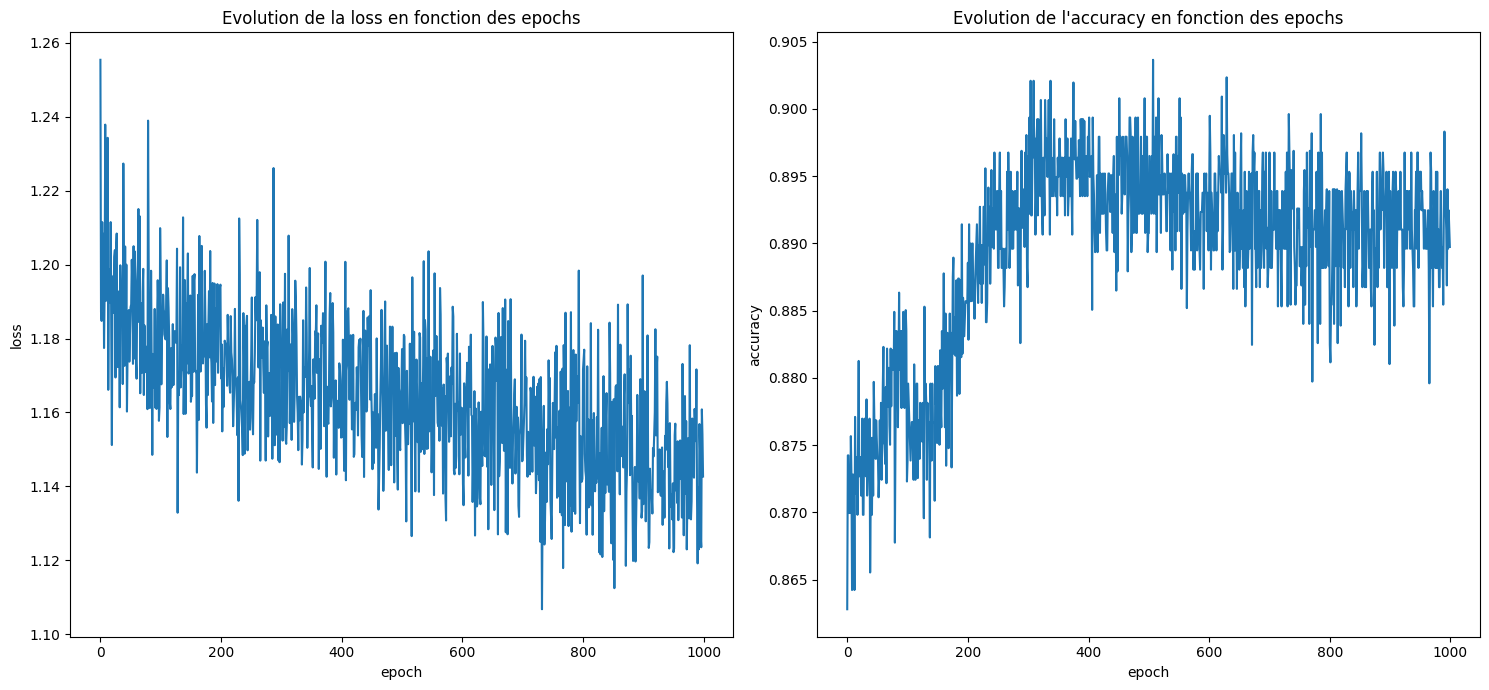

cuda
accuracy train:  0.8911586304505666


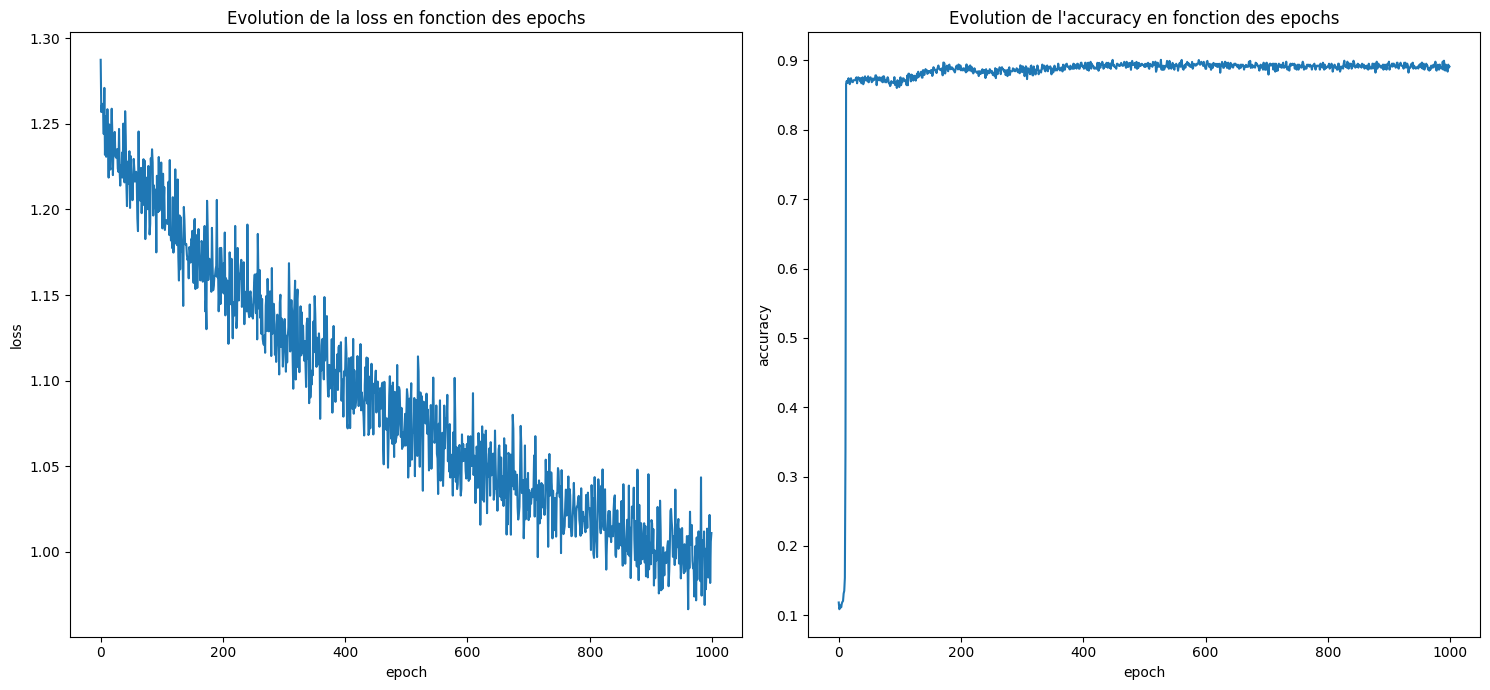

cuda
accuracy train:  0.8821721275647482


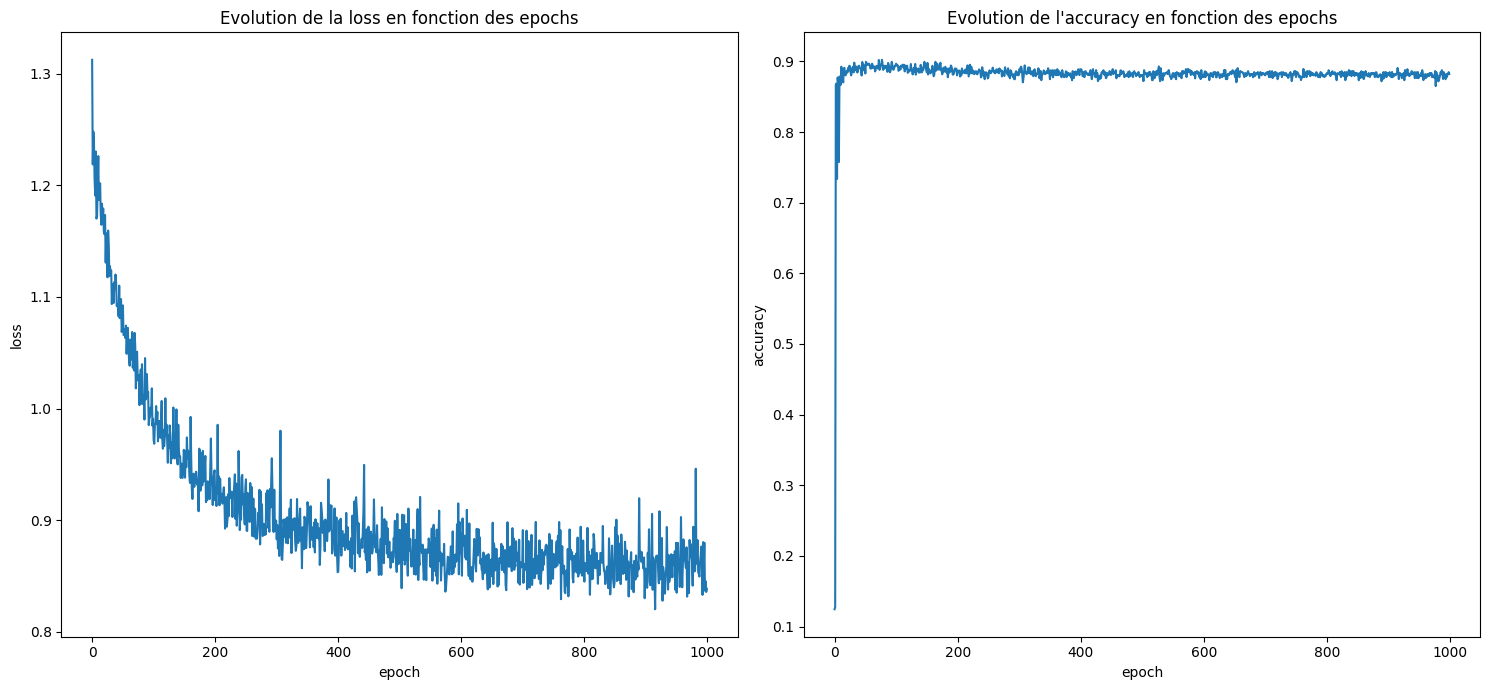

In [16]:
nb_epochs = 1000
models = {}
for lr in [1e-3, 1e-2, 1e-1]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)

    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [17]:
model = models[1e-2]
torch.save(model.state_dict(), "model_far.pth")

Accuracy test:  0.875
Séparabilité:


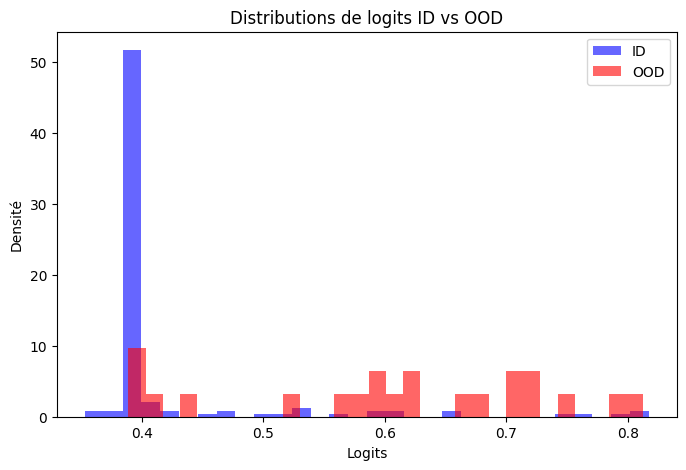

AUC ROC: 0.8896
FPR@TPR95: 0.2792

Correlation ID :  0.828209645502364
Correlation OOD :  0.15871436717868967


,config,tout,video,flow
0,poids_far_ood,0.0812,0.9810,-1.7809
1,perturbation_far_ood_id,0.0086,0.0067,0.0017
2,perturbation_far_ood_ood,0.0346,0.0165,0.0173


In [18]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, FrameworkFactory("far_ood"))

# Near VFA

In [ ]:
framework = FrameworkFactory("vfa")
layer_proc = "ash"

conf = framework.get_confs("id", layer_proc)
pred = framework.get_preds("id", layer_proc)
labels = framework.get_saved_files("label", "id", layer_proc)

for values in pred:
    failure_gt = np.where(pred.transpose()[0] == labels.transpose()[0], 0, 1).reshape(-1,1) # 1 == Failure
    
X = conf
Y = failure_gt
data = {}
X_train, X_test, y_train, y_test = train_test_split(
        X, Y, stratify=Y, test_size=0.2, random_state=42)

data = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}
with open("data_vfa.pkl", 'wb') as f:
    pickle.dump(data, f)

In [34]:
with open("data_vfa.pkl", 'rb') as f:
    data = pickle.load(f)

In [37]:
train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=128) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=128) 

input_dim = 5  #ash sur tous + ash sur aucun + ash video + ash flow + ash audio
hidden_dim = 2
output_dim = 1

# Calcul des poids des classes
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

428 elements (array([0., 1.], dtype=float32), array([313, 115]))
108 elements (array([0., 1.], dtype=float32), array([79, 29]))


2.7217391304347824

cuda
accuracy train:  0.7192826718091965


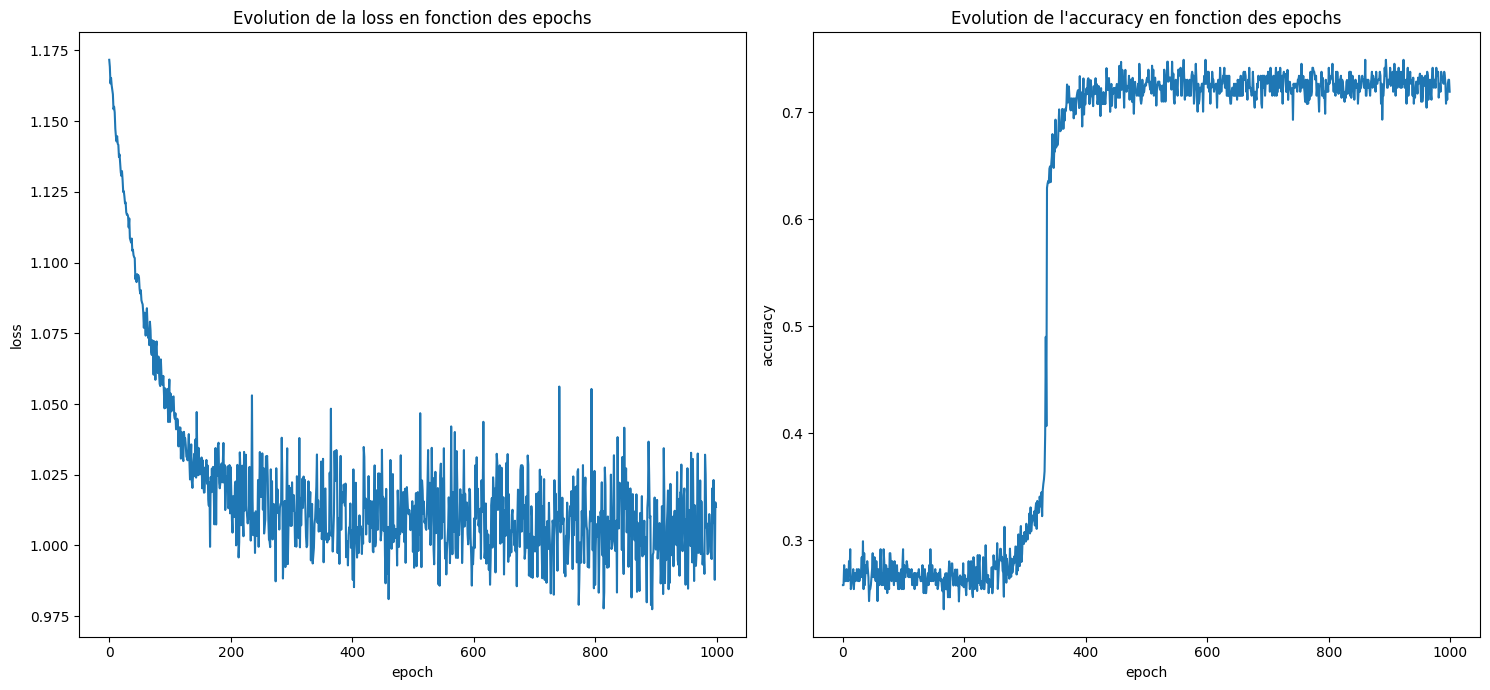

cuda
accuracy train:  0.7057883590459824


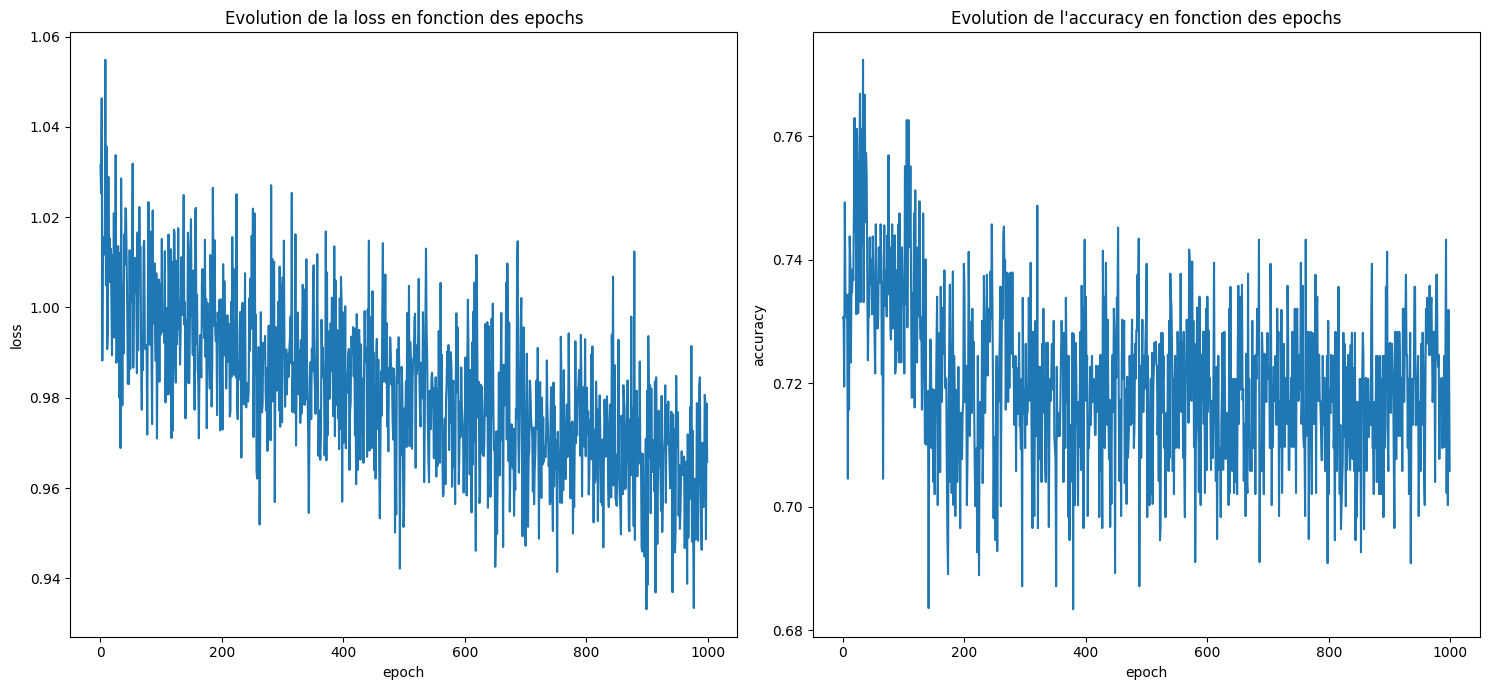

cuda
accuracy train:  0.6919389218091965


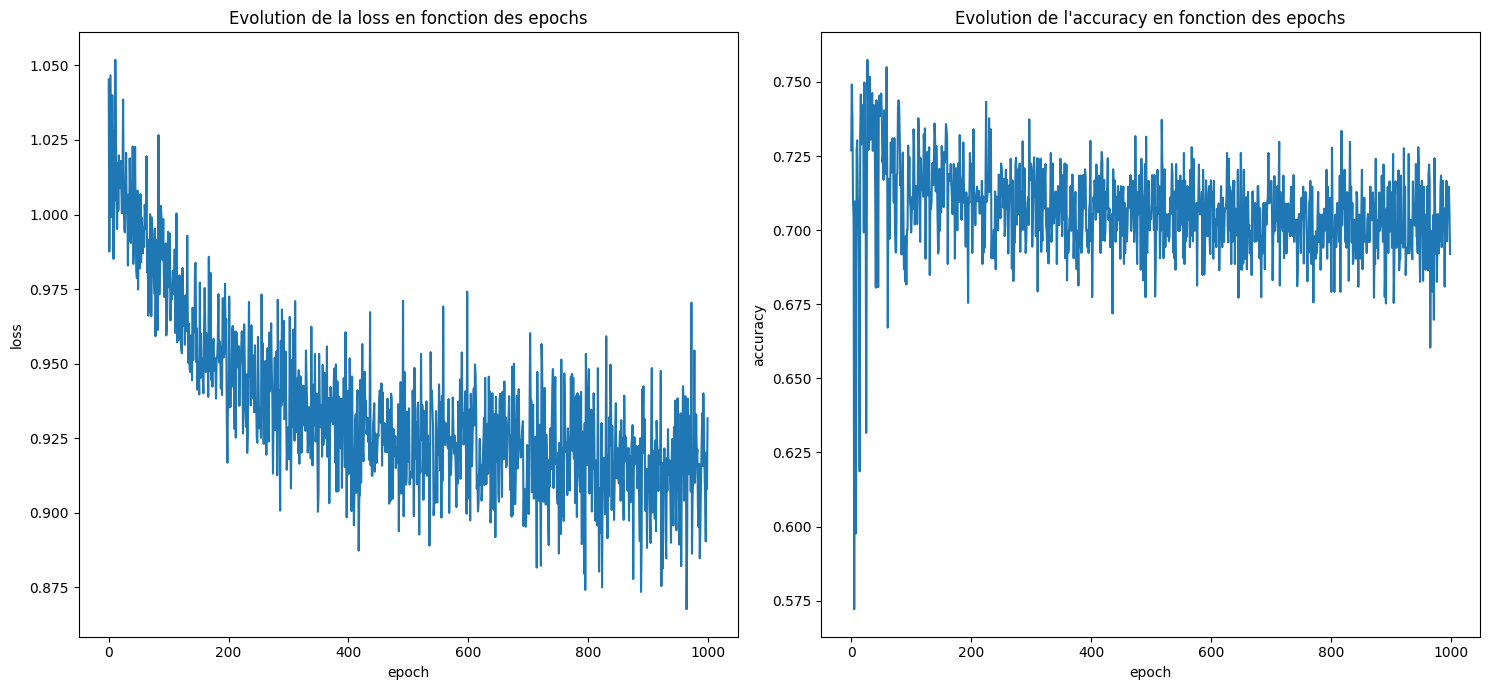

In [40]:
nb_epochs = 1000
models = {}
for lr in [1e-3, 1e-2, 1e-1]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)

    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [41]:
model = models[1e-3]
torch.save(model.state_dict(), "model_vfa.pth")

Accuracy test:  0.7963
Séparabilité:


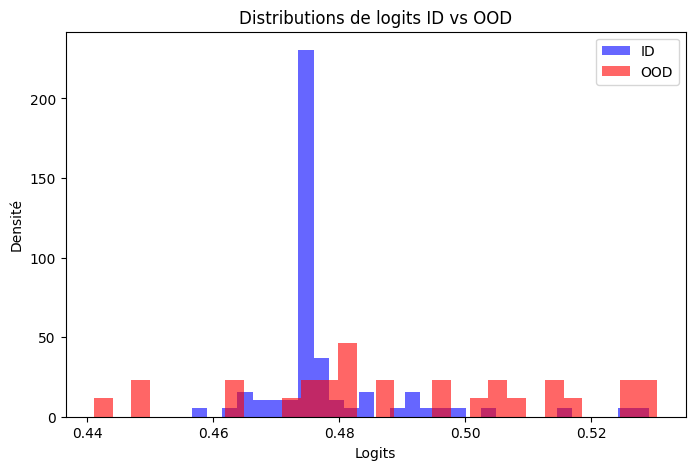

AUC ROC: 0.7115
FPR@TPR95: 1.0



In [43]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, FrameworkFactory("vfa"), correlations=False)